In [16]:
%pip install pandas numpy matplotlib seaborn scikit-learn scipy

Note: you may need to restart the kernel to use updated packages.


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.spatial import Voronoi, voronoi_plot_2d

In [18]:
dataset=pd.read_csv("credit.csv")

In [19]:
dataset.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [20]:
dataset.drop(columns=["CUST_ID"],inplace=True)

In [21]:
dataset.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [22]:
print(dataset.info())
print(dataset.shape)

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CREDIT_LIMIT     

In [23]:
print(dataset.isnull().sum())

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


In [24]:
print(dataset.describe())


            BALANCE  BALANCE_FREQUENCY     PURCHASES  ONEOFF_PURCHASES  \
count   8950.000000        8950.000000   8950.000000       8950.000000   
mean    1564.474828           0.877271   1003.204834        592.437371   
std     2081.531879           0.236904   2136.634782       1659.887917   
min        0.000000           0.000000      0.000000          0.000000   
25%      128.281915           0.888889     39.635000          0.000000   
50%      873.385231           1.000000    361.280000         38.000000   
75%     2054.140036           1.000000   1110.130000        577.405000   
max    19043.138560           1.000000  49039.570000      40761.250000   

       INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
count             8950.000000   8950.000000          8950.000000   
mean               411.067645    978.871112             0.490351   
std                904.338115   2097.163877             0.401371   
min                  0.000000      0.000000             0.000

In [27]:
print(dataset['MINIMUM_PAYMENTS'].mean())
print(dataset['MINIMUM_PAYMENTS'].median())

844.9067666256982
312.343947


In [28]:
dataset["MINIMUM_PAYMENTS"] = dataset["MINIMUM_PAYMENTS"].fillna(dataset["MINIMUM_PAYMENTS"].median())
dataset["CREDIT_LIMIT"] = dataset["CREDIT_LIMIT"].fillna(dataset["CREDIT_LIMIT"].mean())

In [29]:
print(dataset.isnull().sum())

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64


In [30]:
dataset.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='str')

In [31]:
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(dataset)

In [32]:
y_kmeans

array([1, 0, 0, ..., 1, 1, 1], shape=(8950,), dtype=int32)

In [33]:
dataset['Cluster'] = y_kmeans

In [38]:
dataset['Cluster'] 

0       1
1       0
2       0
3       0
4       1
       ..
8945    1
8946    1
8947    1
8948    1
8949    1
Name: Cluster, Length: 8950, dtype: int32

In [40]:
print(sorted(dataset['Cluster'].unique()))

[np.int32(0), np.int32(1), np.int32(2)]


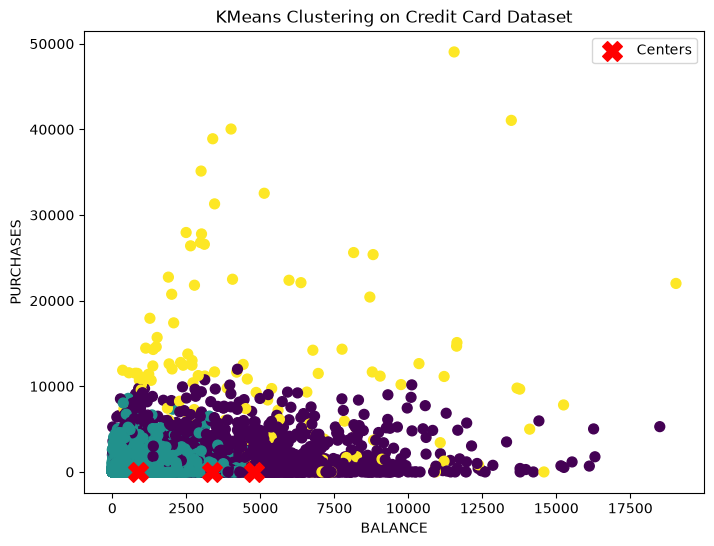

In [41]:
# Step 4: Visualize clusters using 2D (first two features)
plt.figure(figsize=(8,6))
plt.scatter(dataset.iloc[:,0], dataset.iloc[:,2], c=dataset['Cluster'], cmap='viridis', s=50)

# Plot cluster centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label="Centers")

plt.xlabel(dataset.columns[0])
plt.ylabel(dataset.columns[2])
plt.title("KMeans Clustering on Credit Card Dataset")
plt.legend()
plt.show()

In [ ]:
# BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE

sample = [[2000, 0.8, 1500, 200, 300, 100, 0.5, 0.1, 0.3, 0.2, 2, 15, 15000, 1000, 150, 0.1, 12]]
predicted_cluster = kmeans.predict(sample)
print(f"The sample belongs to cluster: {predicted_cluster[0]}")

The sample belongs to cluster: 0


/Users/macbookair/Desktop/ML/VE/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [43]:
# Whats the Average Balance of CLuster 0,1,2
cluster1 = dataset[dataset['Cluster'] == 0]
cluster2 = dataset[dataset['Cluster'] == 1]
cluster3 = dataset[dataset['Cluster'] == 2]

print("Average Balance of Cluster 0:", cluster1['BALANCE'].mean())
print("Average Balance of Cluster 1:", cluster2['BALANCE'].mean())
print("Average Balance of Cluster 2:", cluster3['BALANCE'].mean())

Average Balance of Cluster 0: 3383.184098161094
Average Balance of Cluster 1: 854.8674114598494
Average Balance of Cluster 2: 4797.203573253732


In [46]:
# Whats the Average Credit Limit of CLuster 0,1,2
cluster1 = dataset[dataset['Cluster'] == 0]
cluster2 = dataset[dataset['Cluster'] == 1]
cluster3 = dataset[dataset['Cluster'] == 2]

print("Average Credit Limit of Cluster 0:", cluster1['CREDIT_LIMIT'].mean())
print("Average Credit Limit of Cluster 1:", cluster2['CREDIT_LIMIT'].mean())
print("Average Credit Limit of Cluster 2:", cluster3['CREDIT_LIMIT'].mean())

Average Credit Limit of Cluster 0: 8987.322859511507
Average Credit Limit of Cluster 1: 2741.6655973143497
Average Credit Limit of Cluster 2: 12470.522388059702


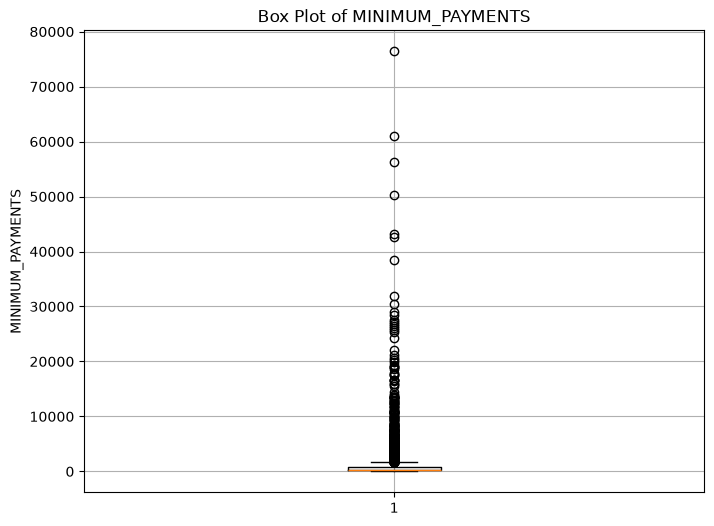

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.boxplot(dataset['MINIMUM_PAYMENTS'])
plt.title('Box Plot of MINIMUM_PAYMENTS')
plt.ylabel('MINIMUM_PAYMENTS')
plt.grid(True)
plt.show()

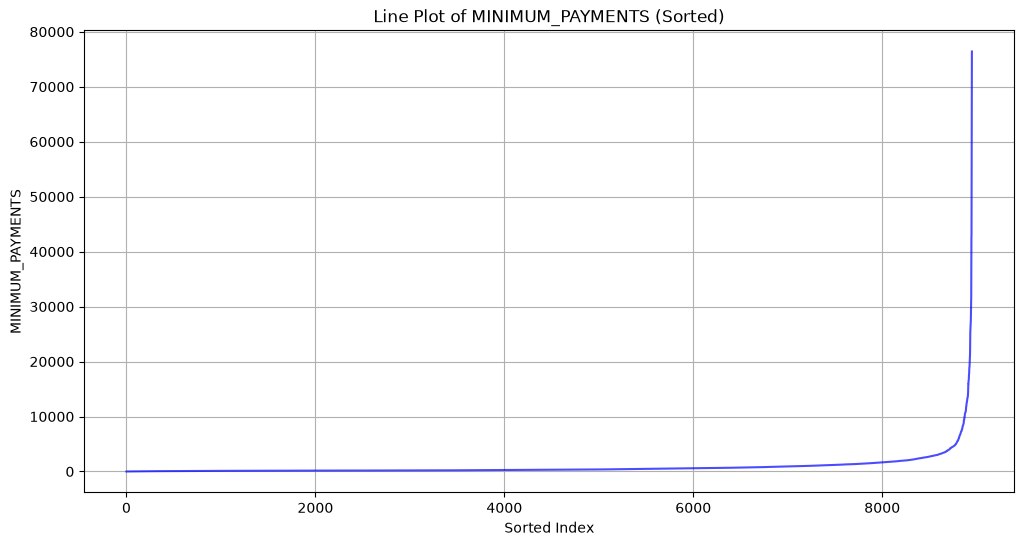

In [36]:
import matplotlib.pyplot as plt
import numpy as np

sorted_payments = np.sort(dataset['MINIMUM_PAYMENTS'].dropna().values)
plt.figure(figsize=(12,6))
plt.plot(sorted_payments, alpha=0.7, color='blue')
plt.title('Line Plot of MINIMUM_PAYMENTS (Sorted)')
plt.xlabel('Sorted Index')
plt.ylabel('MINIMUM_PAYMENTS')
plt.grid(True)
plt.show()